# 데이터 셋 확인

In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import keras
import sklearn
import statsmodels.api as sm

In [2]:
plt.style.use('seaborn-v0_8')
sns.set(font_scale=2.5)
import missingno as msno

In [3]:
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [4]:
os.listdir(".")

['.ipynb_checkpoints',
 '1. Kaggle Guide.ipynb',
 '2_Inferential_Statistics_Test.ipynb',
 'gender_submission.csv',
 'test.csv',
 'train.csv',
 'Untitled.ipynb']

In [5]:
df_train= pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')
df_submit = pd.read_csv('gender_submission.csv')

In [6]:
df_train.shape, df_test.shape, df_submit.shape

((891, 12), (418, 11), (418, 2))

In [7]:
df_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
df_train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [10]:
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
df_train.isnull().sum() / df_train.shape[0]

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64

# 데이터 전처리

In [20]:
# 1. 성별(Sex) 수치화 (남성:0, 여성:1)
df_train['Sex_encoded'] = df_train['Sex'].map({'male':0, 'female':1})

# 나이(Age) 결측치 처리 (중앙값으로 대체)
df_train['Age_filled'] = df_train['Age'].fillna(df_train['Age'].median())

# 3. 요금(Fare) 로그 변환 (데이터가 한쪽으로 쏠려 있어 로그를 취해 완화)
# np.log1p : 데이터에 0이 있을 경우를 대비해 1을 더하고 로그를 취하는 함수
df_train['Fare_log'] = np.log1p(df_train['Fare'])

# 4. 분석에 사용할 독립변수(X)와 종속변수(y) 설정
# Pclass(객실 등급), Sex_encoded(성별), Age_filled(나이), Fare_log(요금)
X = df_train[['Pclass', 'Sex_encoded', 'Age_filled', 'Fare_log']]
y= df_train['Survived']

# 5. 상수항 추가 (statsmodels에서 필수, 모델의 시작점을 잡아주는 역할)
X = sm.add_constant(X)

print("데이터 준비 완료")
X.head()

데이터 준비 완료


,const,Pclass,Sex_encoded,Age_filled,Fare_log
0,1.0,3,0,22.0,2.110213
1,1.0,1,1,38.0,4.280593
2,1.0,3,1,26.0,2.188856
3,1.0,1,1,35.0,3.990834
4,1.0,3,0,35.0,2.202765


# 데이터 전처리 시각적 확인

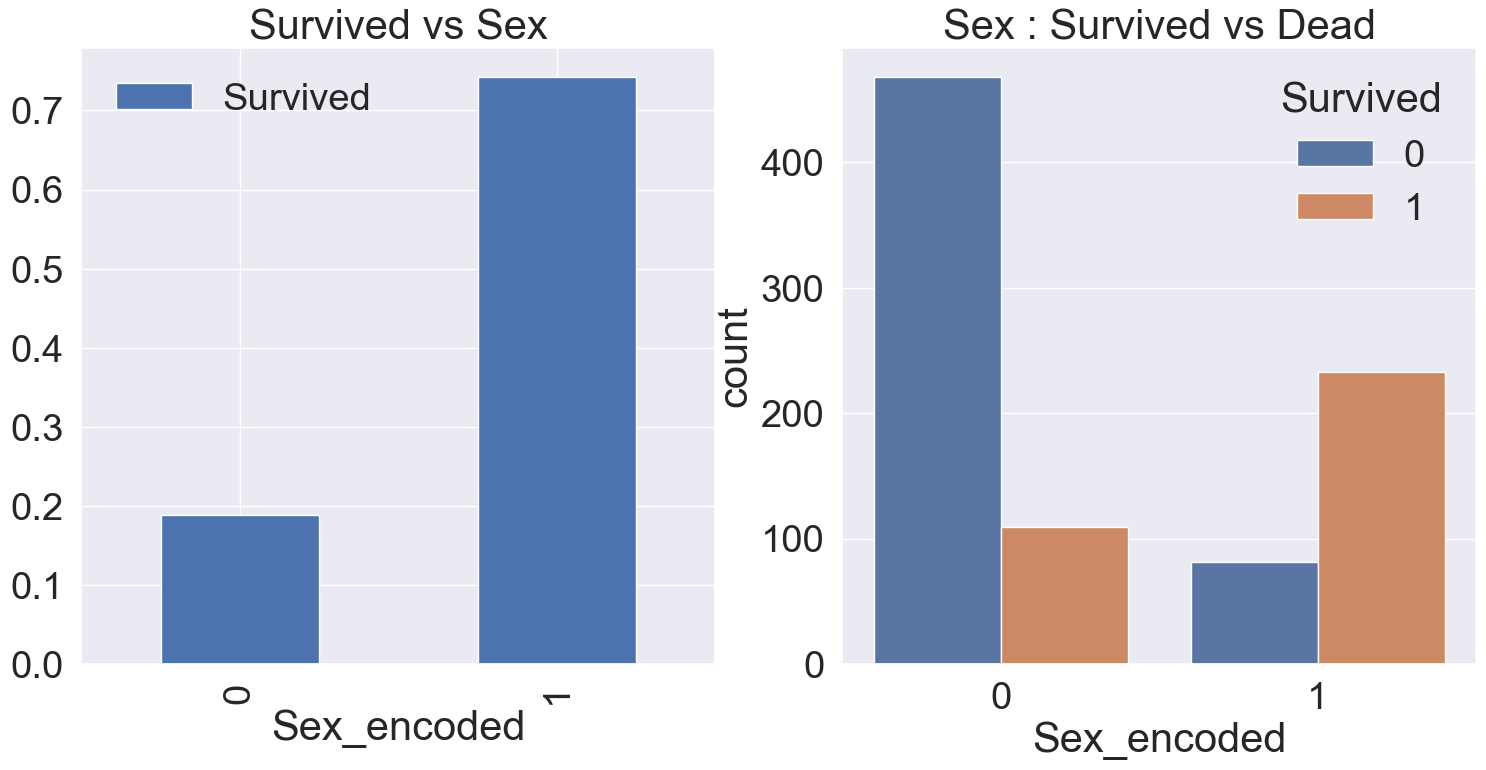

In [25]:
f, ax = plt.subplots(1, 2, figsize=(18, 8))
df_train[['Sex_encoded', 'Survived']].groupby(['Sex_encoded'], as_index=True).mean().plot.bar(ax=ax[0])
ax[0].set_title('Survived vs Sex')
sns.countplot(x='Sex_encoded', hue='Survived', data=df_train, ax=ax[1])
ax[1].set_title('Sex : Survived vs Dead')
plt.show()

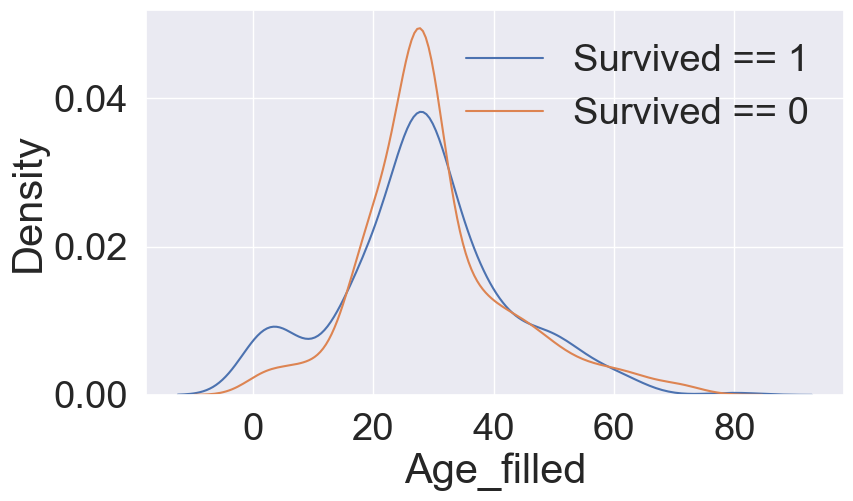

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
sns.kdeplot(df_train[df_train['Survived'] == 1]['Age_filled'], ax=ax)
sns.kdeplot(df_train[df_train['Survived'] == 0]['Age_filled'], ax=ax)
plt.legend(['Survived == 1', 'Survived == 0'])
plt.show()

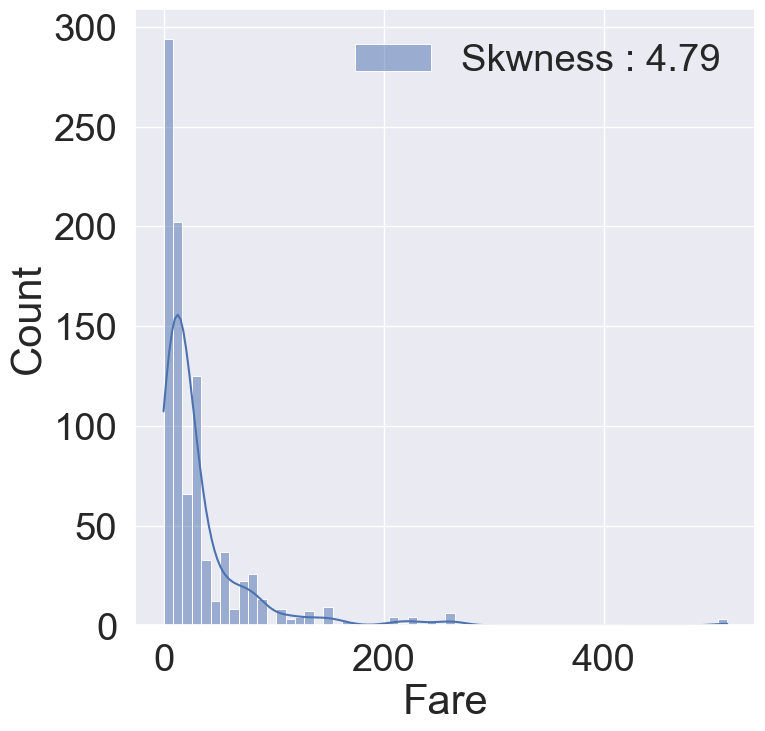

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
g = sns.histplot(df_train['Fare'], color='b', kde=True, label=f"Skwness : {df_train['Fare'].skew():.2f}", ax=ax)
ax.legend(loc='best')
plt.show()

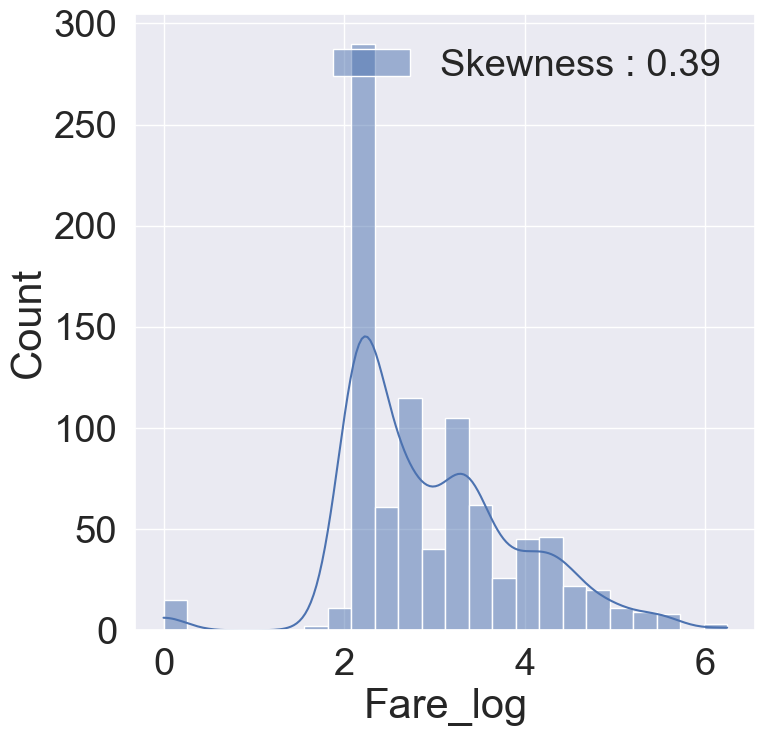

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
sns.histplot(df_train['Fare_log'], color='b', kde=True, label=f"Skewness : {df_train['Fare_log'].skew():.2f}", ax=ax)
ax.legend(loc='best')

# [통계 검정] 생존(Survived)을 결정짓는 핵심적인 요인은 무엇일까?

In [21]:
# 로지스틱 회귀 모델 생성 및 학습
model = sm.Logit(y, X)
results = model.fit()

# 결과 요약 보고서 출력
print(results.summary())

Optimization terminated successfully.
         Current function value: 0.452002
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               Survived   No. Observations:                  891
Model:                          Logit   Df Residuals:                      886
Method:                           MLE   Df Model:                            4
Date:                Sat, 07 Mar 2026   Pseudo R-squ.:                  0.3212
Time:                        10:42:44   Log-Likelihood:                -402.73
converged:                       True   LL-Null:                       -593.33
Covariance Type:            nonrobust   LLR p-value:                 3.224e-81
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           1.9199      0.688      2.793      0.005       0.572       3.267
Pclass         -1.1415    

In [22]:
# 승산비(Odds Ratio)계산
odds_ratios = np.exp(results.params)
print("--- 변수별 승산비(Odds Ratio) ---")
print(odds_ratios)

--- 변수별 승산비(Odds Ratio) ---
const           6.820265
Pclass          0.319342
Sex_encoded    13.464894
Age_filled      0.967504
Fare_log        1.041432
dtype: float64


## 성별, 나이, 객실 등급 등 각 요인이 생존 확률에 미치는 영향력 수치화
**[분석 방법]** : 로지스틱 회귀분석 (Logistic Regression)

**[모델 결과 요약]**
- **성별(Sex)** : 승산비 약 13.46으로 생존에 가장큰 영향을 미침 (여성 우세)
- **객실 등급(Plcass)** : 등급이 낮아질수록 생존 확률 급격히 감소
- **요금(Fare)** : P-value가 0.728로, 객실 등급이 고정된 상태에서는 생존에 유의미한 영향을 주지 못함
- `이후에 VIF 지수를 확인하여 다중공선성을 검토하는 과정이 필요함`

### 로지스틱 회귀분석 결과 해석 (Interpretation)

로지스틱 회귀 모델을 통해 각 변수가 생존에 미치는 통계적 영향력을 분석한 결과입니다.

#### (1) 모델의 적합도 및 유의성 확인
*   **Pseudo R-squ. (0.3212):** 약 32%의 설명력을 가집니다. 복잡한 인적/사회적 변수가 포함된 데이터에서 0.3 이상의 수치는 모델이 데이터를 상당히 잘 설명하고 있음을 의미합니다.
*   **LLR p-value (3.224e-81):** 0에 매우 수렴하는 값으로, 본 회귀 모델이 통계적으로 매우 유의미하게 구성되었음을 증명합니다.

#### (2) 변수별 유의성 검정 (P-value)
`P>|z|` 값이 0.05보다 작은 변수들은 생존 여부를 결정짓는 데 유의미한 변수입니다.
*   **유의미한 변수:** `Sex_encoded` (성별), `Pclass` (객실 등급), `Age_filled` (나이)
*   **유의미하지 않은 변수:** `Fare_log` (요금)
    *   **Insight:** 요금(Fare) 자체보다는 **객실 등급(Pclass)**이 생존에 더 직접적인 영향을 주었습니다. 즉, 비싼 요금을 냈더라도 객실 등급이 낮으면 생존 확률에 큰 이점이 없었다는 통계적 근거를 보여줍니다.

#### (3) 승산비(Odds Ratio) 분석 및 영향력 파악
계수(coef)에 지수함수를 취하여 산출한 승산비는 특정 요인이 확률을 몇 배나 높이는지 보여줍니다.

1.  **성별 (Sex_encoded: 13.46):**
    *   다른 조건이 동일할 때, **여성은 남성에 비해 생존할 확률(Odds)이 약 13.46배 높았습니다.** 모델 내에서 가장 강력한 영향력을 가진 변수입니다.
2.  **객실 등급 (Pclass: 0.319):**
    *   등급 수치가 1단위 커질수록(예: 1등석 → 2등석) 생존 확률은 약 **68% 감소**(1 - 0.319 = 0.681)합니다. 상류층일수록 구조 시 우선순위가 높았음을 시사합니다.
3.  **나이 (Age_filled: 0.967):**
    *   나이가 1살 많아질수록 생존 확률은 약 **3.3%씩 감소**(1 - 0.967 = 0.033)합니다. 고령층보다 어린 승객의 생존율이 더 높았음을 알 수 있습니다.

---

**[종합 결론]**
본 로지스틱 회귀 분석을 통해 타이타닉의 생존은 **'여성'**, **'높은 객실 등급(상류층)'**, **'어린 나이'**일수록 통계적으로 유의미하게 높았음을 확인했습니다. 특히 성별은 생존을 결정짓는 압도적인 요인이었습니다.

In [38]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# 1. 모델을 통해 예측값 계산 (0.5보다 크면 1, 작으면 0으로 분류)
y_pred_prob = results.predict(X)
y_pred = (y_pred_prob > 0.5).astype(int)

# 정확도 계산
accuracy = accuracy_score(y, y_pred)
print(f"전체 정확도 (Accuracy): {accuracy:.4f}")

# 혼동 행렬 (Confusion Matrix)
cm = confusion_matrix(y, y_pred)
print("\n --- 혼동 행렬 (Confusion Matrix) ---")
print(cm)

# 4. 상세 보고서
print("\n --- 상세 리포트 ---")
print(classification_report(y, y_pred))

전체 정확도 (Accuracy): 0.7924

 --- 혼동 행렬 (Confusion Matrix) ---
[[464  85]
 [100 242]]

 --- 상세 리포트 ---
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       549
           1       0.74      0.71      0.72       342

    accuracy                           0.79       891
   macro avg       0.78      0.78      0.78       891
weighted avg       0.79      0.79      0.79       891



**[모델 평가 결과 해석]**
**[전체 정확도 (Accuracy)]** : 79.24% <br>
모델이 전체 승객 891명 중 약 706명의 생존/사망 여부를 정확하게 맞혔음을 의미함. <br>
**[혼동 행렬 (Confusion Matrix)]** : 모델의 정답과 오답의 구체적인 내역 <br>
예측: 사망 (0) 생존 (1)<br>
사망 (0)	464 (정답)	85 (오답 - 사망인데 살았다고 예측)<br>
생존 (1)	100 (오답)	242 (정답)<br>
사망자 예측(464명)을 생존자 예측(242명)보다 더 잘 맞히는 경향이 있음. <br>
**오류 분석** : 모델은 실제로 살았는데 죽었다고 예측한 경우(100명)가 그 반대(85명)보다 조금 더 많다. 즉, 우리 모델은 생존 예측에 있어 약간 보수적이라고 평가할 수 있음.<br>

**상세 리포트 (Precision / Recall)**
- 정밀도 (Precision, 0.74): 모델이 "생존자"라고 예측한 사람 중 실제 생존자의 비율입니다. (예측의 신뢰도) <br>
- 재현율 (Recall, 0.71): 실제 생존자들 중 모델이 찾아낸 비율입니다. (예측의 포괄성) <br>
- F1-score (0.72): 정밀도와 재현율의 균형 점수입니다. 두 수치가 비슷하게 0.7 이상을 기록하고 있어 안정적인 모델이라 볼 수 있습니다. <br>